<a href="https://colab.research.google.com/github/Krish7grg/Cn6005-PortfolioAI/blob/main/Week_6_lab_clustering_Kmean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Data Cleaning: Imputing 0s with Mean ---

--- Running Elbow Method to find optimal K ---
K=1, Inertia: 6144.00
K=2, Inertia: 4961.90
K=3, Inertia: 4342.67
K=4, Inertia: 4011.82
K=5, Inertia: 3727.13
K=6, Inertia: 3517.94
K=7, Inertia: 3336.67
K=8, Inertia: 3205.27
K=9, Inertia: 3030.08
K=10, Inertia: 2997.72


/tmp/ipython-input-2713149985.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].replace(0, np.nan, inplace=True)
/tmp/ipython-input-2713149985.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

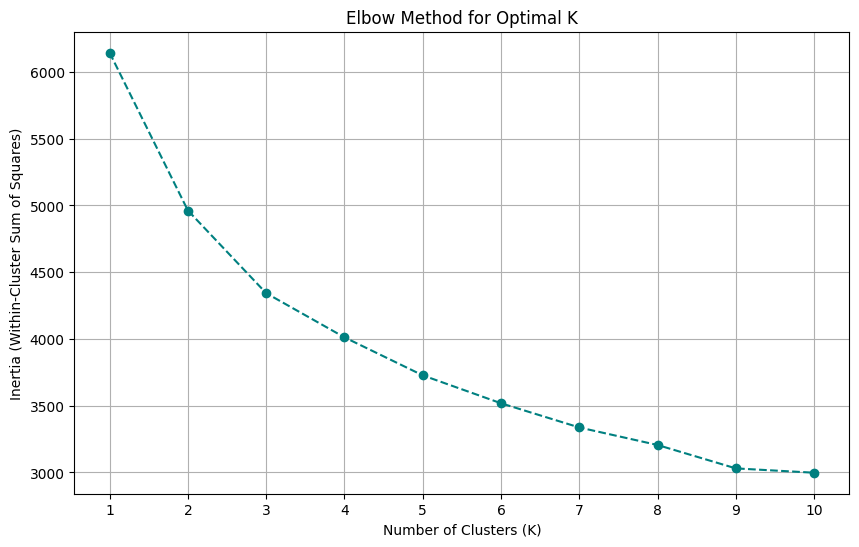


--- Fitting Final K-Means Model with K=2 ---

--- Cluster Analysis ---
Number of samples per cluster:
Cluster
1    421
0    347
Name: count, dtype: int64

--- Cluster Centeroids (Unscaled Mean Feature Values) ---
           Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
Cluster 0         5.82   138.40          78.74          32.74   186.41  35.21   
Cluster 1         2.22   107.91          67.18          26.19   130.11  30.19   

           DiabetesPedigreeFunction    Age  
Cluster 0                      0.51  41.37  
Cluster 1                      0.44  26.54  

Interpretation: Compare Cluster 0 and Cluster 1 means, focusing on Glucose and BMI.


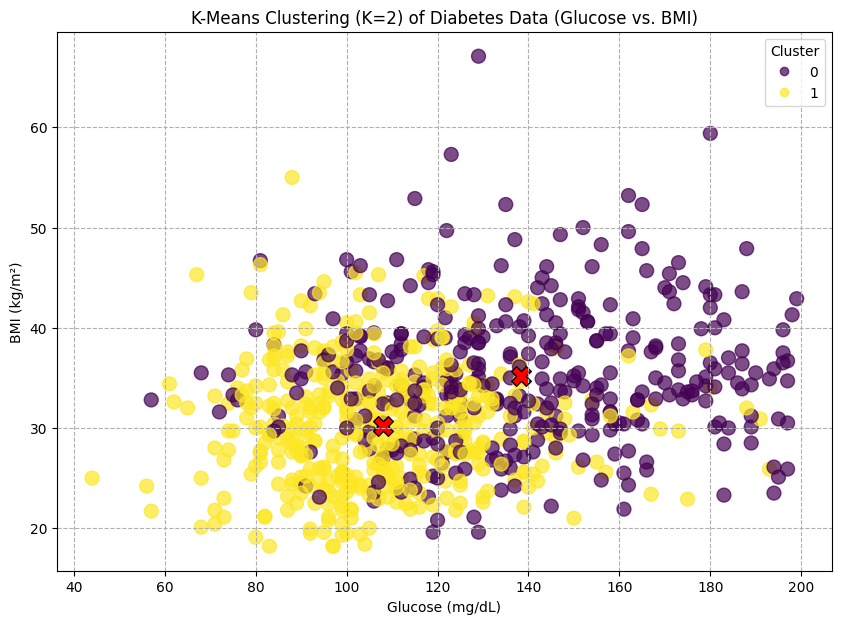


Silhouette Score for K=2: 0.1975


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# --- 1. Data Preparation ---

# Define a mock DataFrame mimicking the Pima Indians Diabetes Dataset for demonstration.
# In a real-world scenario, you would typically load this from a CSV file (e.g., pd.read_csv('diabetes.csv')).

df = pd.read_csv('diabetesN.csv')
df.head()

# Identify columns where a value of 0 is typically invalid (missing data in this medical context).
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Data Cleaning: Replace the invalid '0' values with the mean of that column.
print("--- Data Cleaning: Imputing 0s with Mean ---")
for col in cols_with_zeros:
    # Temporarily replace 0s with NaN
    df[col].replace(0, np.nan, inplace=True)
    # Fill NaN (the original 0s) with the mean of the non-missing values
    df[col].fillna(df[col].mean(), inplace=True)

# Define the features (X) for clustering. We drop the 'Outcome' since K-Means is unsupervised.
X = df.drop('Outcome', axis=1)

# --- 2. Scaling the Data (Crucial for K-Means) ---

# K-Means is a distance-based algorithm (uses Euclidean distance). If features are not scaled,
# features with large values (like Insulin) will disproportionately influence the distance metric.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns) # Convert back to DataFrame for inspection

# --- 3. Finding the Optimal Number of Clusters (The Elbow Method) ---

# The Elbow Method iterates over a range of K values and measures the Inertia
# (Sum of Squared Distances of samples to their closest cluster center).
inertia = []
K_range = range(1, 11)

print("\n--- Running Elbow Method to find optimal K ---")
for k in K_range:
    # Initialize and fit the KMeans model for the current K
    # n_init='auto' selects the best initialization strategy (k-means++)
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_model.fit(X_scaled)
    # Store the inertia value
    inertia.append(kmeans_model.inertia_)
    print(f"K={k}, Inertia: {kmeans_model.inertia_:.2f}")

# Plot the Elbow Curve to visually find the "elbow" point (the K where the drop in inertia slows significantly)
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='teal')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.grid(True)
plt.show() # Display the Elbow Plot

# Based on the expected plot (often K=2 or K=3 for this dataset), we select K=2 for the final model.
optimal_k = 2

# --- 4. K-Means Implementation ---

print(f"\n--- Fitting Final K-Means Model with K={optimal_k} ---")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
# Fit the model and get the cluster labels assigned to each data point
df['Cluster'] = kmeans.fit_predict(X_scaled)
# Inverse transform the centroids to get them back to the original feature scale for human interpretation
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)

# --- 5. Analysis and Interpretation ---

print("\n--- Cluster Analysis ---")
print(f"Number of samples per cluster:\n{df['Cluster'].value_counts()}")

print("\n--- Cluster Centeroids (Unscaled Mean Feature Values) ---")
# Display the cluster centers (the average values for each feature in that cluster)
centers_df = pd.DataFrame(cluster_centers, columns=X.columns)
centers_df.index = [f'Cluster {i}' for i in range(optimal_k)]
print(centers_df.round(2))
print("\nInterpretation: Compare Cluster 0 and Cluster 1 means, focusing on Glucose and BMI.")


# Visualize the clusters using two main features (e.g., Glucose and BMI)
plt.figure(figsize=(10, 7))
# Scatter plot the data points, colored by their assigned cluster
scatter = plt.scatter(df['Glucose'], df['BMI'], c=df['Cluster'], cmap='viridis', s=100, alpha=0.7)
# Plot the red 'X' markers for the cluster centroids
plt.scatter(centers_df['Glucose'], centers_df['BMI'], marker='X', s=200, c='red', label='Centroids', edgecolors='black')
plt.title(f'K-Means Clustering (K={optimal_k}) of Diabetes Data (Glucose vs. BMI)')
plt.xlabel('Glucose (mg/dL)')
plt.ylabel('BMI (kg/m²)')
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.grid(True, linestyle='--')
plt.show()

# --- 6. Reflection on Clustering Quality (Silhouette Score) ---

# Calculate the Silhouette Score: A value close to 1 means the clustering is good (data points are far from neighboring clusters).
score = silhouette_score(X_scaled, df['Cluster'])
print(f"\nSilhouette Score for K={optimal_k}: {score:.4f}")